<a href="https://colab.research.google.com/github/VayuSarangam/CRE-Machine-Learning-3-tiered-PD-model/blob/main/project01_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 — Estimating corporate credit spreads
FIN 453 / FIN 553 — Fall 2026

**Due Friday, October 9, 2026, at 11:59 p.m. Central Time, through Canvas.**
This individual project is worth **20% of the course grade**.

You are building a prediction tool for a credit analyst. Estimate a corporate
bond's **credit spread**, its yield difference relative to a comparable
benchmark bond, from company financial characteristics. Spreads are measured
in **basis points (bps): 100 bps = 1 percentage point of annual yield**.
All bonds share currency, maturity, and seniority. This is a stylized
prediction exercise, not a calibrated pricing model or a causal analysis.

You are provided with two files:

- `development.csv`: 12,000 labeled observations for training and validation.
- `test_features.csv`: 5,000 unlabeled observations for final predictions.
  The instructor alone retains the test labels.

Each row represents a different, independently sampled company. The development
file is sorted by leverage, **not by time**. Your model should predict spreads
for another independent company from this population.

| Part | Task | Points |
|---|---|---:|
| 1 | Split the data and prepare features | 20 |
| 2 | Fit a linear JAX baseline | 30 |
| 3 | Compare three models with cross-validation | 35 |
| 4 | Refit and submit hidden-test predictions | 15 |

**Deliverables:** your completed, executed notebook and `predictions.csv`.
Include two figures (split coverage and training loss), one cross-validation
comparison table, and six short explanations. Two to four sentences per
explanation are enough. No separate report or extra plots are required.
Use fixed seeds and restart/run all cells before submitting.

## Working rules
Use `jax.numpy` for your differentiable loss, **`jax.grad` for all optimization
gradients**, and `jax.jit` for your update. Fit models with your own training
loop; do not replace it with a direct least-squares solve or a prebuilt model
fitting routine. NumPy, pandas, Matplotlib, and Optax are allowed. You may use
Optax to implement the Adam algorithm discussed in class; use one optimizer
consistently. You do **not** need
to compare optimizers or measure execution time.

Work entirely individually. Do not discuss any aspect of the project with
anyone except the instructor, or share/view/compare project code or results.
AI assistance with a specific coding question, debugging, or understanding a
function is allowed. Do not give an AI tool the entire problem or significant
portions and ask for a complete solution. You must understand your submission.

## Setup and data dictionary
Place both CSV files in the notebook's working directory. In Colab, upload
them using the Files panel; upload again if the runtime resets. The supplied
cells load the files.

Packages: `numpy`, `pandas`, `matplotlib`, `jax`, and `optax`. If a package is
missing, install it in a separate setup cell and restart the kernel if needed.

| Column | Meaning |
|---|---|
| `row_id` | Identifier only; never a model feature |
| `leverage` | Debt/assets |
| `interest_coverage` | Earnings/interest expense |
| `liquidity` | Current assets/current liabilities |
| `profitability` | Operating earnings/assets |
| `asset_volatility` | Annualized asset-return volatility |
| `log_size` | Log asset-size index, in fixed arbitrary units |
| `signal_a`, `signal_b` | Additional candidate analyst signals |
| `spread_bps` | Observed spread; development data only |

Train on **t = spread_bps / 100** and multiply predictions by 100 for reporting
and export. This is a fixed unit conversion. Evaluate predictions with MSE;
RMSE = sqrt(MSE) expresses an error in bps. The training loss includes the
classroom factor 1/2; evaluation MSE does not. Do not include the ridge penalty
in validation/test prediction errors.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import jax
import jax.numpy as jnp
import optax

DATA_DIR = Path(".")  # Change only if the supplied CSV files are elsewhere.
FEATURES = ["leverage", "interest_coverage", "liquidity", "profitability",
            "asset_volatility", "log_size", "signal_a", "signal_b"]
TARGET, UNIT = "spread_bps", 100.0
SPLIT_SEED, CV_SEED = 2026, 404
LEARNING_RATE, TRAINING_STEPS, BATCH_SIZE = 0.01, 2000, 256
plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
print({"numpy": np.__version__, "pandas": pd.__version__,
       "jax": jax.__version__, "optax": optax.__version__})


def mse_bps(y_bps, predictions_bps):
    return float(np.mean((np.asarray(y_bps)-np.asarray(predictions_bps))**2))


def rmse_bps(y_bps, predictions_bps):
    return np.sqrt(mse_bps(y_bps, predictions_bps))

{'numpy': '2.1.3', 'pandas': '2.2.3', 'jax': '0.11.1', 'optax': '0.2.8'}


In [ ]:
development_path = DATA_DIR / "development.csv"
if not development_path.exists():
    raise FileNotFoundError("Upload development.csv to DATA_DIR before running this cell.")
development = pd.read_csv(development_path, dtype={"row_id": str})
assert list(development.columns) == ["row_id", *FEATURES, TARGET]
assert development.row_id.is_unique and not development.isna().any().any()
assert np.isfinite(development[FEATURES + [TARGET]].to_numpy()).all()
print("Development observations:", len(development))
display(development.head())

Development observations: 12000


,row_id,leverage,interest_coverage,liquidity,profitability,asset_volatility,log_size,signal_a,signal_b,spread_bps
0,row_b6dd659cb9b0adb38acb,0.100057,7.543133,2.942396,-0.078123,0.393711,8.316000,-1.423670,0.185515,242.359813
1,row_287e87fc1dea660d5a60,0.100165,1.427591,1.334815,0.181396,0.400039,9.064546,1.547084,-0.488185,252.023952
2,row_7951797341fbabe83155,0.100328,6.718288,0.575651,0.137754,0.347869,6.675562,0.226110,-1.258285,245.159185
3,row_7613f174b85d3c19f328,0.100335,2.735904,2.308494,-0.071012,0.621651,6.974965,1.833744,-1.239995,256.647460
4,row_e1ce26a37171620865dd,0.100381,2.373887,1.108179,0.161518,0.567401,5.818393,-0.332160,0.366268,255.591973


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## Part 1 — Splitting and preprocessing (20 points)
Create two 80%/20% train/validation splits: first by slicing the sorted file,
then using **one** seeded NumPy permutation of row indices. Use the same
indices for features and labels. Check the random split's sizes, disjointness,
and complete coverage. Keep that split for Part 2.

**Supplement:** a permutation rearranges observation indices. Applying it to
both features and labels preserves their correspondence. An ordered split here
holds out high-leverage companies; a random split represents another independent
draw from the full population. Randomization need not improve every realized
score. For forecasting, future dates would generally belong after training.

Make **one figure** comparing leverage coverage in ordered and random splits
(two panels are fine). In Part 2, compare the same baseline model on both
splits. No additional models are needed for this figure.

Implement reusable preprocessing: begin with the eight feature columns, learn
each column's mean and standard deviation on TRAINING rows only, reuse those
values on other rows, and add an intercept column of ones. Treat a zero standard
deviation as 1. Never include `row_id` or the target as features.

**Explanation 1:** Why does ordered splitting test extrapolation here? Would
random splitting be appropriate for predicting next year's spreads from earlier years?

Size check passed
Overlap check passed
Coverage check passed
Total rows: 12000
Training rows: 9600
Validation rows: 2400
First 5 training indices: [1985 3001 2743 2705 5087]
Feature matrix shape: (9600, 8)
Feature columns:
Index(['leverage', 'interest_coverage', 'liquidity', 'profitability',
       'asset_volatility', 'log_size', 'signal_a', 'signal_b'],
      dtype='object')


,leverage,interest_coverage,liquidity,profitability,asset_volatility,log_size,signal_a,signal_b
1985,0.231136,3.011503,2.998925,-0.030791,0.340827,4.743125,-0.977522,1.352774
3001,0.298480,4.645294,1.926823,0.025043,0.467789,4.612172,-0.221431,-2.422617
2743,0.281736,8.145601,0.251288,0.073281,0.326621,7.371265,0.099682,-0.172324
2705,0.279148,4.368603,0.909195,-0.005507,0.699822,7.402998,0.426164,-0.075240
5087,0.435977,8.670753,1.249901,0.051772,0.553278,6.493860,-0.307330,1.165783


Expanded: False

Means:
leverage             0.497164
interest_coverage    5.277545
liquidity            1.535357
profitability        0.085082
asset_volatility     0.400327
log_size             6.004361
signal_a            -0.011137
signal_b            -0.015075
dtype: float64

Standard deviations:
leverage             0.230688
interest_coverage    2.733603
liquidity            0.836798
profitability        0.095419
asset_volatility     0.173788
log_size             2.296634
signal_a             0.991896
signal_b             1.010959
dtype: float64
Transformed shape: (9600, 9)
Data type: float32
First 5 intercept values: [1. 1. 1. 1. 1.]
Means after standardization: [ 0.0000000e+00  7.9472862e-10  1.0927518e-09 -8.9406965e-10
 -2.9802322e-10  9.9341080e-10  0.0000000e+00  7.9472862e-10]


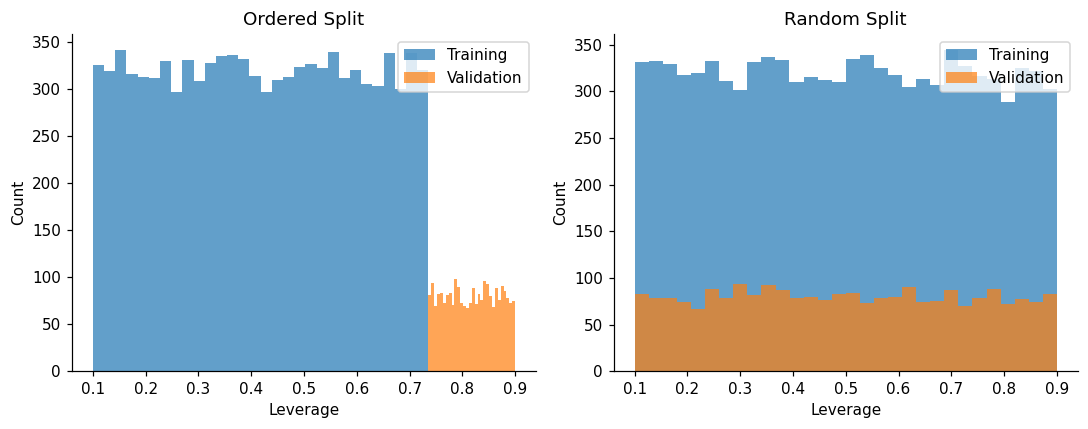

In [ ]:
def split_indices(n, seed=SPLIT_SEED):
    """Return random train/validation index arrays (80% / 20%)."""
    # TODO: One permutation, then split it; add size/overlap/coverage checks.
    rng = np.random.default_rng(seed)

    # Randomize the row indices
    indices = rng.permutation(n)

    # Split into training and validation sets
    training_size = int(0.8 * n)
    training_set = indices[0:training_size]
    validation_set = indices[training_size:n]

    # Size check
    if len(training_set) == training_size and len(validation_set) == n - training_size:
        print("Size check passed")
    else:
        print("Size check failed")

    # Overlap check
    if len(np.intersect1d(training_set, validation_set)) == 0:
        print("Overlap check passed")
    else:
        print("Overlap check failed")

    # Coverage check
    combo_set = np.concatenate((training_set, validation_set))

    if len(np.unique(combo_set)) == n:
        print("Coverage check passed")
    else:
        print("Coverage check failed")

    return training_set, validation_set

n = len(development)
training_size = int(0.8 * n)

ordered_training_set = np.arange(0, training_size)
ordered_validation_set = np.arange(training_size, n)

random_training_set, random_validation_set = split_indices(n)

print("Total rows:", n)
print("Training rows:", len(training_set))
print("Validation rows:", len(validation_set))
print("First 5 training indices:", training_set[:5])

def feature_matrix(frame, expanded=False):
    """Raw feature columns WITHOUT an intercept; extend in Part 3."""
    # TODO: Start with frame[FEATURES]; add the three specified terms in Part 3.

    features = frame[FEATURES]
    return features

training_data = development.iloc[training_set]
training_features = feature_matrix(training_data)

print("Feature matrix shape:", training_features.shape)
print("Feature columns:")
print(training_features.columns)

display(training_features.head())

def fit_preprocessor(frame, expanded=False):
    """Return a dict with expanded, mean, scale fitted to these training rows."""
    # TODO: Construct raw features; compute training-only means and scales.
    features = feature_matrix(frame, expanded)
    mean = features.mean()

    #scale factor is sample (n-1) with ddof
    scale = features.std(ddof=0)
    scale[scale == 0] = 1

    return {"expanded": expanded, "mean": mean, "scale": scale}

preprocessor = fit_preprocessor(training_data)

print("Expanded:", preprocessor["expanded"])

print("\nMeans:")
print(preprocessor["mean"])

print("\nStandard deviations:")
print(preprocessor["scale"])

def transform(frame, preprocessor):
    """Apply saved preprocessing; return float32 features with an intercept."""
    # TODO: Use saved statistics, not statistics calculated from frame.

    features = feature_matrix(frame, preprocessor["expanded"])
    mean = preprocessor["mean"]
    scale = preprocessor["scale"]

    standardized_features = (features - mean) / scale
    intercept = np.ones((len(standardized_features), 1))

    features_with_intercept = np.concatenate((intercept, standardized_features), axis=1)
    return features_with_intercept.astype(np.float32)

preprocessor = fit_preprocessor(training_data)
X_train = transform(training_data, preprocessor)

print("Transformed shape:", X_train.shape)
print("Data type:", X_train.dtype)
n_train = len(X_train)

print("First 5 intercept values:", X_train[0:5, 0])
print("Means after standardization:", X_train[0:len(X_train), 1:9].mean(axis=0))


# TODO: Build both splits, check indices, and make the coverage figure below.
#coverage figures
ordered_train_leverage = development.iloc[ordered_training_set]["leverage"]
ordered_val_leverage = development.iloc[ordered_validation_set]["leverage"]

random_train_leverage = development.iloc[random_training_set]["leverage"]
random_val_leverage = development.iloc[random_validation_set]["leverage"]

# Stub definitions do nothing until you call them; complete before calling.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(ordered_train_leverage, bins=30, alpha=0.7, label="Training")
axes[0].hist(ordered_val_leverage, bins=30, alpha=0.7, label="Validation")
axes[0].set_title("Ordered Split")
axes[0].set_xlabel("Leverage")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(random_train_leverage, bins=30, alpha=0.7, label="Training")
axes[1].hist(random_val_leverage, bins=30, alpha=0.7, label="Validation")
axes[1].set_title("Random Split")
axes[1].set_xlabel("Leverage")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


**Explanation 1:** _Write your answer here._

## Part 2 — Linear regression with JAX (30 points)
With design matrix A, coefficients theta, and t = spread_bps/100, implement

$$L(\theta)=\frac{1}{2m}\sum_{i=1}^m(A_i\theta-t_i)^2.$$

Obtain the gradient with **`jax.grad`** and compile the update with `jax.jit`.
By default, `jax.grad(loss)` differentiates the first argument: theta in the
supplied function signature. Calling the resulting function returns a
gradient, not updated parameters.
No analytical-gradient derivation or implementation is requested. Write one
reusable training function, resetting parameters AND optimizer state on every
call. Reuse it throughout the project.

Suggested settings: Adam, learning rate 0.01, 2,000 updates, batch size 256, and
a fixed sampling seed. Mini-batch row indices must select A and t together.
Optax handles Adam's internal updates; you implement the loss and training loop.
Use one optimizer, not a comparison study. You may adjust settings if needed
for sensible training, then use the same settings for all candidates in Part 3.
These suggested settings assume Adam; another optimizer may need a different
learning rate or number of updates.

**Optax API reference** (not a complete training loop):

```python
optimizer = optax.adam(LEARNING_RATE)
state = optimizer.init(theta)                         # once per fresh fit
updates, state = optimizer.update(grads, state, theta) # on each update
theta = optax.apply_updates(theta, updates)
```
Here `grads` is the gradient you compute on the current mini-batch. Keep the
returned state for the next update; do not reinitialize it inside the loop.
You still implement the loss, mini-batch selection, jitted update, and loop.
API details: [JAX grad](https://docs.jax.dev/en/latest/_autosummary/jax.grad.html)
and [Optax](https://optax.readthedocs.io/en/latest/getting_started.html).

Check that the loss is scalar, the gradient has theta's shape and finite values,
and training reduces the loss. Make **one training-loss plot** for the random
baseline. Report its training and validation RMSE in bps. Also report validation
RMSE for the same linear model fitted to the ordered training split (with its
OWN scaler), and for a constant prediction equal to the random training mean.
A few printed numbers are enough.

**Explanation 2:** What do `jax.grad` and `jax.jit` each do in your code? State
the shapes of A, theta, predictions, and the scalar loss.

**Explanation 3:** Compare your results. Why learn feature means/scales on
training rows only? Why does falling training loss alone not establish good
predictions on new companies?

In [ ]:
def loss(theta, A, t, lam=0.0):
    """Scalar half-MSE; add the slopes-only ridge penalty in Part 3."""
    # TODO: Use jnp operations; return a scalar. lam=0 for the baseline.
    raise NotImplementedError("Complete Part 2; add ridge in Part 3.")


def train(A, y_bps, lam=0.0, seed=40):
    """Return fitted theta and loss history; scale y internally."""
    # TODO: Fresh theta/state, jax.grad(loss), jitted update, training loop.
    # Return (theta, history), documenting what you store in history.
    raise NotImplementedError("Complete Part 2.")

# TODO: Fit both baselines, check gradient shape/values, plot one loss history,
#       and print training/validation RMSEs and the constant benchmark's RMSE.

**Explanation 2:** _Write your answer here._

**Explanation 3:** _Write your answer here._

## Part 3 — Three models and three-fold cross-validation (35 points)
Compare **exactly three** candidates. Extend the feature builder with only
these three columns, computed from the original, unstandardized features:

$$\text{leverage}^2,\qquad \text{interest\_coverage}^2,\qquad
  \text{leverage}\times\text{asset\_volatility}.$$

Construct raw columns first; learn means/scales for ALL columns on the training
rows of that fit. Add the intercept after standardization.

| Candidate | Features before intercept | Ridge lambda |
|---|---|---:|
| Linear | Original 8 columns | 0 |
| Expanded | Original 8 plus the 3 specified terms | 0 |
| Expanded + ridge | Same 11 columns | 0.01 |

Use the supplied ridge value, without a penalty search. Extend the loss to

$$L_\lambda(\theta)=\frac{1}{2m}\sum_i(A_i\theta-t_i)^2
                    +\frac{\lambda}{2}\sum_{j=1}^{p-1}\theta_j^2.$$

theta[0] is the intercept and is **not** penalized. Lecture 4 penalized every
coefficient and divided the penalty by N. Here the penalty is **not divided
by m**, so the numerical values of lambda are not directly comparable between
those conventions. Follow the formula above. The data term is a mean, not
a sum; lambda is not the optimizer's learning rate.

**Cross-validation tutorial:** shuffle all development indices once using
`CV_SEED` and divide them into three equal folds. Fit on two folds, score the
third, and repeat so each fold is held out once. Reuse the SAME folds for all
candidates. This requires **nine fresh fits**, not one fit scored nine times.
The original Part 1 split is replaced by these folds; the separate test stays
untouched. Each fit needs training-fold preprocessing and fresh theta AND
optimizer state.

Make one table of the three held-out MSEs and their mean for each candidate.
Compute validation MSE in bps², **without** a penalty or factor 1/2. Select the
smallest mean MSE; an exact tie goes to the candidate appearing first above.
Freeze the choice before Part 4. No CV plot or further model search is required.
Ridge need not have the lowest CV error; report what you find. Choosing an
unpenalized model is valid when its mean CV MSE is lowest.

**Explanation 4:** How can this model describe a curved relationship while
remaining linear in theta? What does ridge encourage?

**Explanation 5:** Why reset/refit preprocessing, theta, and optimizer state
inside each fold? Why is a final hidden test still needed after CV?

In [ ]:
CANDIDATES = [
    {"name": "Linear", "expanded": False, "lam": 0.0},
    {"name": "Expanded", "expanded": True, "lam": 0.0},
    {"name": "Expanded + ridge", "expanded": True, "lam": 0.01},
]

In [ ]:
# TODO: Extend feature_matrix and loss with the specified terms and penalty.
# TODO: Use one CV_SEED permutation and np.array_split(..., 3) for the folds.
# TODO: Fit a NEW scaler/model for each candidate/fold using only the other
#       two folds; evaluate held-out predictions with mse_bps.
# TODO: Display the 3-row comparison table and save selected_candidate (a dict above).
# Reuse the Part 2 training function and optimizer settings.

**Explanation 4:** _Write your answer here._

**Explanation 5:** _Write your answer here._

## Part 4 — Final refit and common hidden test (15 points)
Freeze the chosen candidate and training settings. Refit its preprocessing
and model on **all** development rows. Load the shared test features below,
apply the final scaler without refitting, and predict in bps. Everyone predicts
the same observations. Do not drop/change IDs or use IDs as features.

The supplied export helper writes `row_id,predicted_spread_bps` and checks basic
formatting. Submit `predictions.csv` and your completed notebook. Test labels
and an interim leaderboard are not provided for further tuning.
In Colab, download `predictions.csv` from the Files panel and download your
completed notebook via **File > Download > Download .ipynb** before submitting
both files through Canvas. Submit the CSV produced by the helper; do not edit
or re-save it in a spreadsheet. Preserve the complete `row_...` identifiers.

**Explanation 6:** Why can you now refit on all development rows? Identify where
your code reuses the final scaler and converts predictions to bps. State the
selected model and its mean CV MSE.

**Grading emphasis:** correct implementation, reproducibility, and explanations.
Part 4: final refit (5 points), valid reproducible prediction export (5), and
explanation/reproducibility checks (5). Hidden-test RMSE helps the instructor
assess the pipeline; tiny differences do not create leaderboard bonuses or
separate grade rankings.

In [ ]:
test_path = DATA_DIR / "test_features.csv"
if not test_path.exists():
    raise FileNotFoundError("Upload test_features.csv to DATA_DIR before this cell.")
test_features = pd.read_csv(test_path, dtype={"row_id": str})
assert list(test_features.columns) == ["row_id", *FEATURES]
assert test_features.row_id.is_unique and not test_features.isna().any().any()
assert np.isfinite(test_features[FEATURES].to_numpy()).all()
assert not set(test_features.row_id).intersection(development.row_id)
print("Common test observations:", len(test_features))


def save_predictions(features, predictions_bps, output_path="predictions.csv"):
    values = np.asarray(predictions_bps, dtype=float)
    if values.shape != (len(features),) or not np.isfinite(values).all():
        raise ValueError("Supply one finite prediction in bps per test row.")
    if features.row_id.isna().any() or not features.row_id.is_unique:
        raise ValueError("Test row IDs must be nonmissing and unique.")
    result = pd.DataFrame({"row_id": features.row_id.to_numpy(), "predicted_spread_bps": values})
    result.to_csv(output_path, index=False)
    print("Wrote", output_path, "with", len(result), "predictions.")
    return result

In [ ]:
# TODO: Refit the selected model and its scaler on ALL development observations.
# TODO: Apply the final scaler to test_features; predict and convert to bps.
# Then call: save_predictions(test_features, predictions_bps)
# Do not fit a scaler on the test or put test rows into cross-validation.

**Explanation 6:** _Write your answer here._

## Submission checklist
- Two figures, one CV comparison table, six concise explanations.
- Your JAX loss, `jax.grad`, and jitted update fit every requested model.
- Each fit learns preprocessing only from its own training rows.
- Final fitting uses all development rows; test IDs are not features.
- `predictions.csv` has one finite prediction in bps per test row.
- Fixed seeds, package versions, and a clean restart/run-all.
- Submit only your completed notebook and prediction CSV through Canvas.